# CAB320 Assignment 2 - Transfer Learning
Anthony Vanderkop, Thierry Peynot, Frederic Maire (Jupyter Notebook template: 2025)


## Instructions:
The functions and classes defined in this module will be called by the marker without modification. 
You should complete the functions and classes according to their specified interfaces.

No partial marks will be awarded for functions that do not meet the specifications of the interfaces.


In [1]:
### LIBRARY IMPORTS ###
import os
import numpy as np
import keras.applications as ka
import keras
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score

Hi this is xavier's testing thingo if you can read this you're awesome and also Zach Coglan

## Task 1
Implement the my_team()function 

In [2]:
def my_team():
    '''
    Return the list of the team members of this assignment submission as a list
    of triplet of the form (student_number, first_name, last_name)
    
    '''
    return [(11885807, "Zach", "Coglan"), ]

In [3]:
# my_team()

## Task 2
Download the small_flower_dataset from Canvas and load the data

In [4]:
def load_data(path):
    '''
    Load in the dataset from its home path. Path should be a string of the path
    to the home directory the dataset is found in. Should return a numpy array
    with paired images and class labels.
    
    Insert a more detailed description here.
    '''
    # Using Keras Utils to load the given dataset
    dataset = keras.utils.image_dataset_from_directory(path, labels="inferred", label_mode="categorical", color_mode="rgb", batch_size=None, image_size=(256, 256))

    # Convert to numpy array
    dataset = dataset.as_numpy_iterator()
    dataset = np.fromiter(dataset, dtype="object")

    return dataset

In [5]:
dataset = load_data("small_flower_dataset\small_flower_dataset")

Found 1000 files belonging to 5 classes.


<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
C:\Users\cogla\AppData\Local\Temp\ipykernel_13824\2977283360.py:1: SyntaxWarning: invalid escape sequence '\s'
  dataset = load_data("small_flower_dataset\small_flower_dataset")


## Task 3
Prepare your training, validation and test sets for the non-accelerated version of transfer learning.

In [6]:
def reorder_data(X, Y):
    Nx = len(X)
    Ny = len(Y)
    if Nx != Ny:
        raise ValueError('X and Y should have the same number of rows')
    pi = np.random.permutation(Nx)
    X = X[pi]
    Y = Y[pi]
    return X, Y

def split_data(X, Y, train_fraction, randomize=False, eval_set=True):
    """
    Split the data into training and testing sets. If eval_set is True, also create
    an evaluation dataset. There should be two outputs if eval_set there should
    be three outputs (train, test, eval), otherwise two outputs (train, test).
    
    To see what type train, test, and eval should be, refer to the inputs of 
    transfer_learning().
    
    Insert a more detailed description here.
    """
    # Get the dimensions of X and Y
    Nx = len(X)
    Ny = len(Y)
    
    # Check if X and Y have the same number of rows
    if Nx != Ny:
        raise ValueError('X and Y should have the same number of rows')
    
    # Calculate the number of samples for training
    Ne = round(train_fraction * Nx)

    # Randomize the data if randomize is True
    if randomize:
        X, Y = reorder_data(X, Y)
    
    # Split the data into training set
    Xtr, Ytr = X[:Ne], Y[:Ne]

    # If eval_set is True, split the test set into test and eval sets
    if eval_set:
        Ne_eval = round(0.5 * (1 - train_fraction) * Nx) + Ne
        Xte, Xev = X[Ne:Ne_eval], X[Ne_eval:]
        Yte, Yev = Y[Ne:Ne_eval], Y[Ne_eval:]
        return (Xtr, Ytr), (Xev, Yev), (Xte, Yte)
    else:
        Xte, Yte = X[Ne:], Y[Ne:]
        return (Xtr, Ytr), (Xte, Yte)

In [7]:
X = np.array([x for x, y in dataset])
Y = np.array([y for x, y in dataset])

train_set, eval_set, test_set = split_data(X, Y, 0.8, randomize=True, eval_set=True)

Report: Include details of how you have split the data to perform this training. Ensure the split is reasonable and does not introduce class imbalance during training

The dataset was split into 3 parts, 80% for training, and 10% each for testing and validation. 80% for training was used as because of the smaller size of the dataset, a larger portion was used than the 70% that is standard as I believed that more training would be more valuable than greater than single 2 decimal place precision when in validation or testing. ti was important to set randomise to True as it will mix up the order of the dataset which means that simply taking from the first 80% will have a variety of classes and not just the first 4 classes, leaving the last one to be tested and validated on which it would not be able to do.


## Task 4
Using the tf.keras.applications module download a pretrained MobileNetV2 network. 

In [8]:
def load_model():
    '''
    Load in a model using the tf.keras.applications model and return it.
    Insert a more detailed description here
    '''
    model = ka.MobileNetV2(input_shape=(256, 256, 3), weights="imagenet", include_top=False)
    model.trainable = False

    return model
    

In [9]:
model = load_model()

C:\Users\cogla\AppData\Local\Temp\ipykernel_13824\1924931953.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  model = ka.MobileNetV2(input_shape=(256, 256, 3), weights="imagenet", include_top=False)


## Task 5
Replace the last layer of the downloaded neural network with a Dense layer of the appropriate shape for the 5 classes of the small flower dataset {(x1,t1), (x2,t2),..., (xm,tm)}.

In [10]:
# Add dense layer to model
flatten_layer = keras.layers.Flatten()(model.output)
last_Dense = keras.layers.Dense(5, activation="softmax")(flatten_layer)
model = keras.Model(inputs=model.input, outputs=last_Dense)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 128, 128,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 128, 128,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 128, 128,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 128, 128,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 128, 128,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 128, 128,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 129, 129,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 64, 64,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 64, 64,    │      2,304 │ block_1_depthwis

 Total params: 2,667,589 (10.18 MB)

 Trainable params: 409,605 (1.56 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Task 6
Compile and train your model with an SGD optimizer using the following parameters learning_rate=0.01, momentum=0.0, nesterov=False. (NB: The SGD class description can be found at https://keras.io/api/optimizers/sgd/  )

This function first makes an exact copy of the model by using keras's built in clone model function that coppies all the layers, then sets the weights to be the same as the clone model does not do this and would mess up the pre-trained portion of the model. It then compiles the model using categorical crossentropy as a loss funcition as it is a standard los function for classifiers of this nature, the stochastic gradient decent optimiser as required from this task whith the appropriate parameters from the parameters input to the function assigned. the accuracy metric was also added as it was required for tasks 7 and 8. Finaly it trains this model with the given train and evaluation datasets with the number of ecpoch set to be 15 as a guess at a reasonable value as to not allow for too much overfitting but also allow time for the model to reach its peak accuracy. 

In [11]:
def transfer_learning(train_set, eval_set, model, parameters):
    '''
    Implement and perform standard transfer learning here.

    Inputs:
        - train_set: list or tuple of the training images and labels in the
            form (images, labels) for training the classifier
        - eval_set: list or tuple of the images and labels used in evaluating
            the model during training, in the form (images, labels)
        - model: an instance of tf.keras.applications.MobileNetV2
        - parameters: list or tuple of parameters to use during training:
            (learning_rate, momentum, nesterov)


    Outputs:
        - model : an instance of tf.keras.applications.MobileNetV2
        - history : an instance of tf.keras.callbacks.history

    '''
    new_model = keras.models.clone_model(model)
    new_model.set_weights(model.get_weights())
    new_model.compile(loss="categorical_crossentropy", optimizer=keras.optimizers.SGD(learning_rate=parameters[0], momentum=parameters[1], nesterov=parameters[2]), metrics=["accuracy"])
    history = new_model.fit(train_set[0], train_set[1], validation_data=eval_set, epochs=15)
    return new_model, history

In [12]:
trained_model, history = transfer_learning(train_set, eval_set, model, (0.01, 0.0, False))

Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.2250 - loss: 141.3207 - val_accuracy: 0.2600 - val_loss: 123.8099
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.3537 - loss: 88.0389 - val_accuracy: 0.3500 - val_loss: 62.2078
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.4450 - loss: 57.6565 - val_accuracy: 0.4500 - val_loss: 36.0303
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.5188 - loss: 42.1011 - val_accuracy: 0.4600 - val_loss: 32.9026
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 838ms/step - accuracy: 0.5013 - loss: 47.2610 - val_accuracy: 0.4000 - val_loss: 55.7320
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 765ms/step - accuracy: 0.6187 - loss: 23.1475 - val_accuracy: 0.3900 - val_loss: 88.2929
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 759ms/step - accuracy: 0.7800 - loss: 11.8081 - val_accuracy: 0.5500 - val_loss: 18.1962
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 693ms/step - accuracy: 0.7613 - loss: 10.7847 - val

## Task 7
Plot the training and validation errors and accuracies of standard transfer 

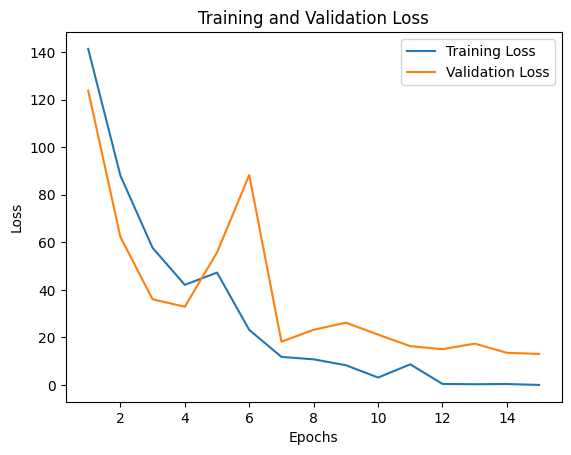

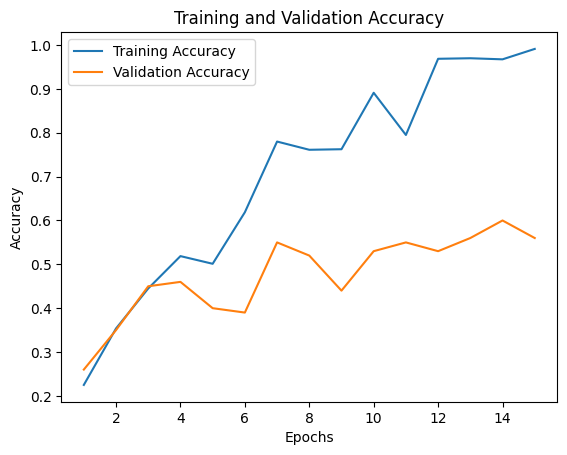

In [13]:
## Your Code ------------ Still To DO ---------------
epochs = np.array(range(1, 16))

plt.plot(epochs, history.history["loss"], label="Training Loss")
plt.plot(epochs, history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

plt.plot(epochs, history.history["accuracy"], label="Training Accuracy")
plt.plot(epochs, history.history["val_accuracy"], label="Validation Accuracy")
plt.legend()
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

These graphs show that the loss between the training a validation dataset are pretty similar throughout the training of the dataset and improvement platoued at epoch 11. The accuracy tells a different story, at epoch 9 the validation accuracy flattend out at around 60%, however the training accuracy continued to increase indicating some overfitting.

## Task 8
Experiment with 3 different orders of magnitude for the learning rate. Plot the results and discuss in the below markdown cell

In [14]:
## Your code
trained_model_low_lr, history_low_lr = transfer_learning(train_set, eval_set, model, (0.001, 0.0, False))
trained_model_high_lr, history_high_lr = transfer_learning(train_set, eval_set, model, (0.1, 0.0, False))

Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 30s 894ms/step - accuracy: 0.2338 - loss: 12.6859 - val_accuracy: 0.2900 - val_loss: 13.3336
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 824ms/step - accuracy: 0.3212 - loss: 8.4641 - val_accuracy: 0.3500 - val_loss: 9.9726
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 791ms/step - accuracy: 0.4013 - loss: 7.1837 - val_accuracy: 0.5200 - val_loss: 2.9764
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 831ms/step - accuracy: 0.5500 - loss: 3.0266 - val_accuracy: 0.4200 - val_loss: 9.1843
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 787ms/step - accuracy: 0.5362 - loss: 4.0775 - val_accuracy: 0.2500 - val_loss: 6.3205
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 862ms/step - accuracy: 0.6450 - loss: 2.2753 - val_accuracy: 0.4400 - val_loss: 3.9615
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 795ms/step - accuracy: 0.8087 - loss: 0.7688 - val_accuracy: 0.4900 - val_loss: 2.4609
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 757ms/step - accuracy: 0.6513 - loss: 1.9319 - val_ac

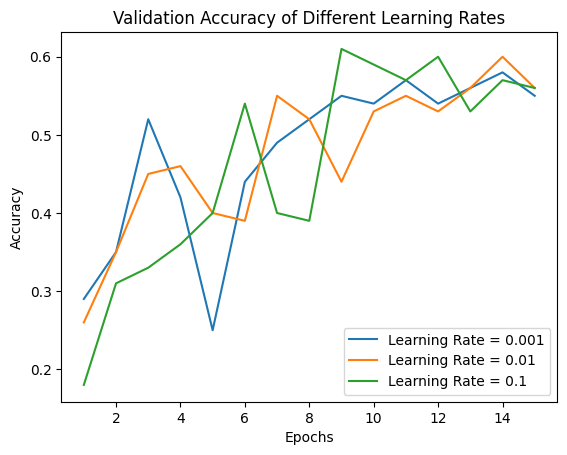

In [24]:
plt.plot(epochs, history_low_lr.history["val_accuracy"], label="Learning Rate = 0.001")
plt.plot(epochs, history.history["val_accuracy"], label="Learning Rate = 0.01")
plt.plot(epochs, history_high_lr.history["val_accuracy"], label="Learning Rate = 0.1")
plt.legend()
plt.title("Validation Accuracy of Different Learning Rates")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

### Task 8 Analysis and discussion


All three leaning rates provide similar results in terms of final accuracy and the the time it took to plateau. However, the biggest difference and most important take away is how smooth the line is. The first medel trained with a learning rate of 0.01 has some jumps up and down, whereas the high learning rate model with a value of 0.1 jump over 15% back and forth mulitple times and the final model with a learning rate of 0.001 has a far more consistent path. This is as with higher learning rates, the model is more likely to overshoot the optimal weights and actually get worse.

## Task 9
Run the resulting classifier on your test dataset using results from the best learning rate you experimented with. Compute and display the confusion matrix. 

4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step  


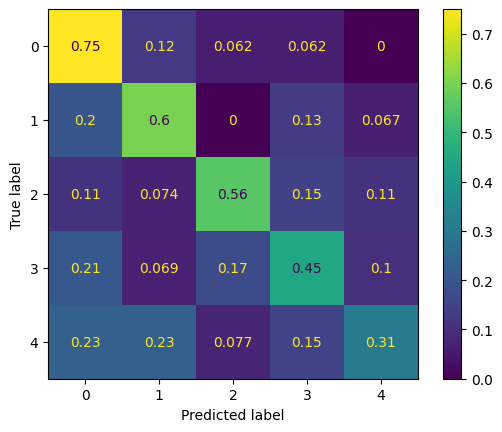

In [16]:
## Your code
predictions = trained_model_low_lr.predict(test_set[0]).argmax(axis=1)
test_set_labels = test_set[1].argmax(axis=1)
cm = confusion_matrix(test_set_labels, predictions, normalize="true")
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()


## Task 10
Compute the precision, recall, and f1 scores of your classifier on the test dataset using the best learning rate. Report on the results and comment. 

In [17]:
## Your code
precision = precision_score(test_set_labels, predictions, average="weighted")
recall = recall_score(test_set_labels, predictions, average="weighted")
f1 = f1_score(test_set_labels, predictions, average="weighted")

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")


Precision: 0.5488383838383839
Recall: 0.53
F1 Score: 0.527603100436792


### Task 10 Analysis and discussion

The similar values for both precision and recall, and thus F1 score, show that the model is guessing evenly, not guessing one category more than others out of safety / exploiting the dataset. However these scores are not overly great, while ~0.6 is 3 times better than what is expected out of random chance (0.2), for a more complex model with a larger dataset these scores could be easily 0.9+.

## Task 11
Perform k-fold validation on the dataset with k = 3. 

In [18]:
def k_fold_validation(features, ground_truth, classifier, k=2):
    '''
    Inputs:
        - features: np.ndarray of features in the dataset
        - ground_truth: np.ndarray of class values associated with the features
        - fit_func: f
        - classifier: class object with both fit() and predict() methods which
        can be applied to subsets of the features and ground_truth inputs.
        - predict_func: function, calling predict_func(features) should return
        a numpy array of class predictions which can in turn be input to the 
        functions in this script to calculate performance metrics.
        - k: int, number of sub-sets to partition the data into. default is k=2
    Outputs:
        - avg_metrics: np.ndarray of shape (3, c) where c is the number of classes.
        The first row is the average precision for each class over the k
        validation steps. Second row is recall and third row is f1 score.
        - sigma_metrics: np.ndarray, each value is the standard deviation of 
        the performance metrics [precision, recall, f1_score]
    '''
    
    #split data
    ### YOUR CODE HERE ###
    
    #go through each partition and use it as a test set.
    for partition_no in range(k):
        #determine test and train sets
        ### YOUR CODE HERE###
        
        #fit model to training data and perform predictions on the test set
        classifier.fit(train_features, train_classes)
        predictions = classifier.predict(test_features)
        
        #calculate performance metrics
        ### YOUR CODE HERE###
    
    #perform statistical analyses on metrics
    ### YOUR CODE HERE###
    
    raise NotImplementedError
    return avg_metrics, sigma_metrics

In [19]:
## Your code
# xx = k_fold_validation(xx, xx, xx, xx)

Comment on the results and any differences with the previous test-train split. 
Repeat with two different values for k and comment on the results. 

### Comments and analysis

## Task 12
With the best learning rate that you found in the previous task, add a non-zero momentum to the training with the SGD optimizer (consider 3 values for the momentum). Report on how your results change.  

In [20]:
## Code

### Report

## Task 13
Now using “accelerated transfer learning”, repeat the training process (k-fold validation is optional this time). You should prepare your training, validation and test sets based on {(F(x1).t1), (F(x2),t2),...,(F(xm),tm)}, and re-do Task 12. 


In [21]:
def accelerated_learning(train_set, eval_set, model, parameters):
    '''
    Implement and perform accelerated transfer learning here.

    Inputs:
        - train_set: list or tuple of the training images and labels in the
            form (images, labels) for training the classifier
        - eval_set: list or tuple of the images and labels used in evaluating
            the model during training, in the form (images, labels)
        - model: an instance of tf.keras.applications.MobileNetV2
        - parameters: list or tuple of parameters to use during training:
            (learning_rate, momentum, nesterov)


    Outputs:
        - model : an instance of tf.keras.applications.MobileNetV2

    '''
    raise NotImplementedError
    return model


Plot and comment on the results and differences against the standard implementation of transfer learning. 

In [22]:
## Code

### Your Comments:

## Task 14
Use the results of all experiments to make suggestions for future work and recommendations for parameter values to anyone else who may be interested in a similar implementation of transfer learning. 

### Your answer: